In [58]:
import os
import pandas as pd

In [59]:
excel_file_path1 = 'C:/Users/ASUS/OneDrive/Documents/中信兄弟/Season_data/2024_non_trackman.xlsx'
excel_file_path2 = 'C:/Users/ASUS/OneDrive/Documents/中信兄弟/Season_data/2023_non_trackman.xlsx'
sheet_name = 'Sheet1'

In [60]:
data2024 = pd.read_excel(excel_file_path1, sheet_name=sheet_name)
data2023 = pd.read_excel(excel_file_path2, sheet_name=sheet_name)

In [61]:
col = ['umpireInChief','stadium','bHand','pHand','strikes','balls','side','inning','coordX','coordY','pType','call','result']

In [62]:
data2024= data2024[col]
data2023= data2023[col]

In [63]:
data = pd.concat([data2023, data2024], ignore_index=True)

In [64]:
data

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result
0,蘇建文,臺中洲際棒球場,L,L,0,0,AWAY,1,-25.54,-63.07,FF,B,NaN
1,蘇建文,臺中洲際棒球場,L,L,0,1,AWAY,1,24.51,-45.40,FF,B,NaN
2,蘇建文,臺中洲際棒球場,L,L,0,2,AWAY,1,38.80,-63.41,FF,B,NaN
3,蘇建文,臺中洲際棒球場,L,L,0,3,AWAY,1,-22.83,24.92,FF,S,NaN
4,蘇建文,臺中洲際棒球場,L,L,1,3,AWAY,1,-0.38,-37.28,FF,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193017,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,0,0,AWAY,9,22.26,-9.19,FF,FT,NaN
193018,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,1,0,AWAY,9,-42.54,-57.26,FO,SW,NaN
193019,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,2,0,AWAY,9,-3.69,-21.03,FO,H,1B
193020,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,R,0,0,AWAY,9,-27.78,35.48,FF,S,NaN


In [65]:
df = data[col]
df

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result
0,蘇建文,臺中洲際棒球場,L,L,0,0,AWAY,1,-25.54,-63.07,FF,B,NaN
1,蘇建文,臺中洲際棒球場,L,L,0,1,AWAY,1,24.51,-45.40,FF,B,NaN
2,蘇建文,臺中洲際棒球場,L,L,0,2,AWAY,1,38.80,-63.41,FF,B,NaN
3,蘇建文,臺中洲際棒球場,L,L,0,3,AWAY,1,-22.83,24.92,FF,S,NaN
4,蘇建文,臺中洲際棒球場,L,L,1,3,AWAY,1,-0.38,-37.28,FF,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
193017,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,0,0,AWAY,9,22.26,-9.19,FF,FT,NaN
193018,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,1,0,AWAY,9,-42.54,-57.26,FO,SW,NaN
193019,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,2,0,AWAY,9,-3.69,-21.03,FO,H,1B
193020,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,R,0,0,AWAY,9,-27.78,35.48,FF,S,NaN


In [66]:
result_items = df['result'].unique()
result_items

array([nan, 'uBB', 'SH', 'GO', 'SO', '1B', 'FO', 'FC', 'E', 'GIDP', 'HR',
       'SF', 'HBP', '3B', '2B', 'IBB', 'ID', 'TP', 'IGNORE', 'DP', 'D3S',
       'IH'], dtype=object)

In [67]:
df = df[~df['result'].isin(['GO','2B', '1B', 'FO', 'SH', 'E', 'GIDP', 'FC','HBP', 'HR', '3B', 'IBB', 'SF', 'IGNORE', 'DP', 'D3S', 'ID', 'IH'])]

In [68]:
call_items = df['call'].unique()
call_items

array(['B', 'S', 'SW', 'F', 'FT', 'TRY_BUNT', nan, 'H', 'CS', 'FT_MISS',
       'FOUL_BUNT', 'BUNT'], dtype=object)

In [69]:
df = df[~df['call'].isin(['F', 'SW', 'CS', 'FT_MISS', 'FOUL_BUNT','FT','TRY_BUNT', 'H', 'BUNT'])]
df= df.dropna(subset=['call'])

In [70]:
name_mapping = {
    'FF':'直球', 
    'CH':'變速球', 
    'FC':'卡特球', 
    'CU':'曲球', 
    'FO':'指叉球',
    'SL':'滑球', 
    'SI':'伸卡球',
    'KN':'彈指曲球', 
    'EP':'小便球'
}

# 新增一列"球員"，根据"Pitcher"列的值匹配中文名
df['球種'] = df['pType'].map(name_mapping)

In [71]:
df

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result,球種
0,蘇建文,臺中洲際棒球場,L,L,0,0,AWAY,1,-25.54,-63.07,FF,B,NaN,直球
1,蘇建文,臺中洲際棒球場,L,L,0,1,AWAY,1,24.51,-45.40,FF,B,NaN,直球
2,蘇建文,臺中洲際棒球場,L,L,0,2,AWAY,1,38.80,-63.41,FF,B,NaN,直球
3,蘇建文,臺中洲際棒球場,L,L,0,3,AWAY,1,-22.83,24.92,FF,S,NaN,直球
4,蘇建文,臺中洲際棒球場,L,L,1,3,AWAY,1,-0.38,-37.28,FF,S,NaN,直球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193008,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,0,0,HOME,8,21.85,-8.77,FF,S,NaN,直球
193009,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,0,HOME,8,73.51,-54.30,FF,B,NaN,直球
193010,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,1,HOME,8,130.84,-46.00,FF,B,NaN,直球
193014,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,0,0,AWAY,9,-7.16,-20.61,FF,S,NaN,直球


In [72]:
umpire_items = df['umpireInChief'].unique()
umpire_items

array(['蘇建文', '紀華文', '張展榮', '林金達', '彭楚雲', '王俊宏', '羅鈞鴻', '吳家維', '江春緯',
       '楊崇煇', '邱景彥', '蔡豐澤', '陳均瑋', '范元淦', '尤志欽', '劉世偉'], dtype=object)

In [73]:
feild_items = df['stadium'].unique()
feild_items

array(['臺中洲際棒球場', '樂天桃園棒球場', '臺南市立棒球場', '新北市立新莊棒球場', '澄清湖棒球場',
       '臺北市立天母棒球場', '斗六棒球場', '嘉義市立棒球場', '花蓮縣立德興棒球場', '臺東棒球村第一棒球場',
       '臺北大巨蛋 Taipei Dome', '澄清湖棒球場 \tChengcing Lake Baseball Stadium',
       '臺中洲際棒球場 \tTaichung Intercontinental Baseball Stadium',
       '臺北市立天母棒球場 Tianmu Baseball Stadium',
       '新北市立新莊棒球場 Xinzhuang Baseball Stadium',
       '樂天桃園棒球場 Rakuten Taoyuan Baseball Stadium',
       '臺南市立棒球場 Tainan Municipal Baseball Stadium', '台東棒球村第一棒球場',
       '嘉義市立棒球場 \tChiayi Baseball Field',
       '斗六棒球場 \tDouliu Baseball Stadium',
       '嘉義縣立棒球場 \tChiayi County Baseball Stadium'], dtype=object)

In [74]:
stadiums_of_interest = [
    '臺北市立天母棒球場 Tianmu Baseball Stadium',
    '臺中洲際棒球場 \tTaichung Intercontinental Baseball Stadium',
    '臺中洲際棒球場',
    '斗六棒球場 \tDouliu Baseball Stadium',
    '臺北市立天母棒球場',
    '斗六棒球場'
]

# 使用 loc 方法筛选数据
df2 = df[df['stadium'].isin(stadiums_of_interest)]



In [75]:
# 假設 df 是你的 DataFrame
def is_in_strike_zone(x, y):
    strike_zone_x_min = -50
    strike_zone_x_max = 50
    strike_zone_y_min = -50
    strike_zone_y_max = 50
    return "好球" if (strike_zone_x_min <= x <= strike_zone_x_max and strike_zone_y_min <= y <= strike_zone_y_max) else "壞球"

# 新增 isStrikeZone 欄位
df2["實際好壞球"] = df2.apply(lambda row: is_in_strike_zone(row["coordX"], row["coordY"]), axis=1)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14856\1723899082.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["實際好壞球"] = df2.apply(lambda row: is_in_strike_zone(row["coordX"], row["coordY"]), axis=1)


In [76]:
df2

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result,球種,實際好壞球
0,蘇建文,臺中洲際棒球場,L,L,0,0,AWAY,1,-25.54,-63.07,FF,B,NaN,直球,壞球
1,蘇建文,臺中洲際棒球場,L,L,0,1,AWAY,1,24.51,-45.40,FF,B,NaN,直球,好球
2,蘇建文,臺中洲際棒球場,L,L,0,2,AWAY,1,38.80,-63.41,FF,B,NaN,直球,壞球
3,蘇建文,臺中洲際棒球場,L,L,0,3,AWAY,1,-22.83,24.92,FF,S,NaN,直球,好球
4,蘇建文,臺中洲際棒球場,L,L,1,3,AWAY,1,-0.38,-37.28,FF,S,NaN,直球,好球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193008,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,0,0,HOME,8,21.85,-8.77,FF,S,NaN,直球,好球
193009,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,0,HOME,8,73.51,-54.30,FF,B,NaN,直球,壞球
193010,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,1,HOME,8,130.84,-46.00,FF,B,NaN,直球,壞球
193014,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,L,R,0,0,AWAY,9,-7.16,-20.61,FF,S,NaN,直球,好球


In [77]:
# 設定篩選 1
umpire_name = "劉世偉"
#batter_name = "王威晨"
call = "S"
#strikes = 2
#inning = [7,8,9]
#pitchtype = ["卡特球"]
#side = "HOME"
pHand = "L"
bHand = ['R']
filtered_df = df2[df2['bHand'].isin(bHand)
                ]
filtered_df

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result,球種,實際好壞球
7,蘇建文,臺中洲際棒球場,R,L,0,0,AWAY,1,48.32,-14.85,FF,S,NaN,直球,好球
55,蘇建文,臺中洲際棒球場,R,L,0,0,HOME,2,36.31,-17.02,CU,S,NaN,曲球,好球
57,蘇建文,臺中洲際棒球場,R,L,2,0,HOME,2,-73.17,-67.57,CH,B,NaN,變速球,壞球
59,蘇建文,臺中洲際棒球場,R,L,0,0,AWAY,3,-41.23,-74.97,CU,B,NaN,曲球,壞球
63,蘇建文,臺中洲際棒球場,R,L,2,1,AWAY,3,60.28,77.78,FF,B,NaN,直球,壞球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193003,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,2,1,AWAY,8,-82.72,-83.26,CH,B,NaN,變速球,壞球
193008,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,0,0,HOME,8,21.85,-8.77,FF,S,NaN,直球,好球
193009,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,0,HOME,8,73.51,-54.30,FF,B,NaN,直球,壞球
193010,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,1,HOME,8,130.84,-46.00,FF,B,NaN,直球,壞球


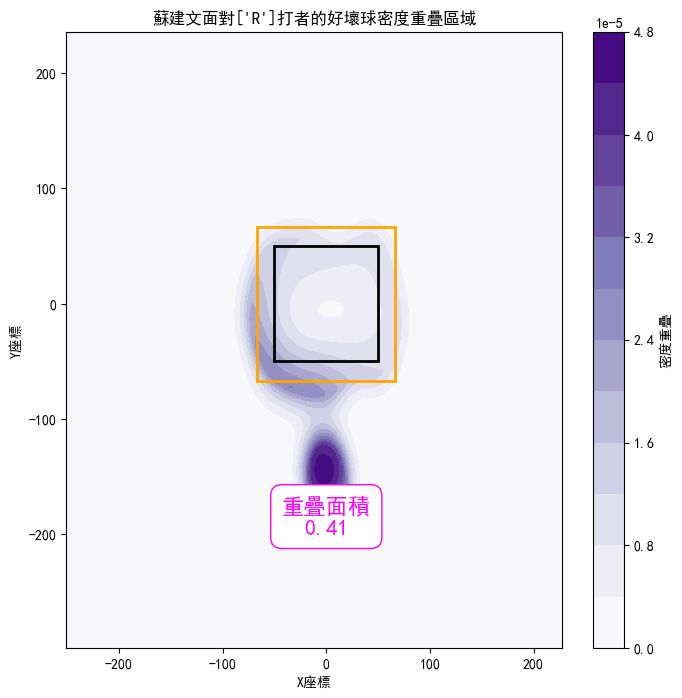

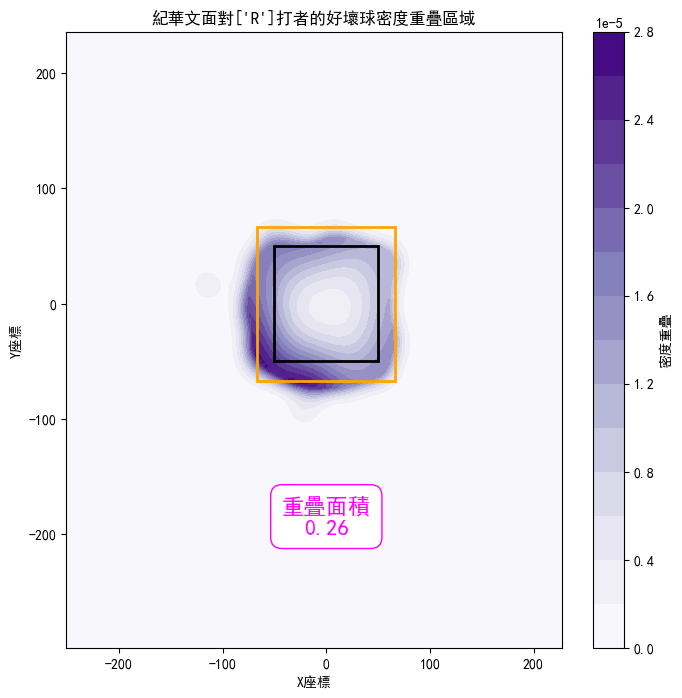

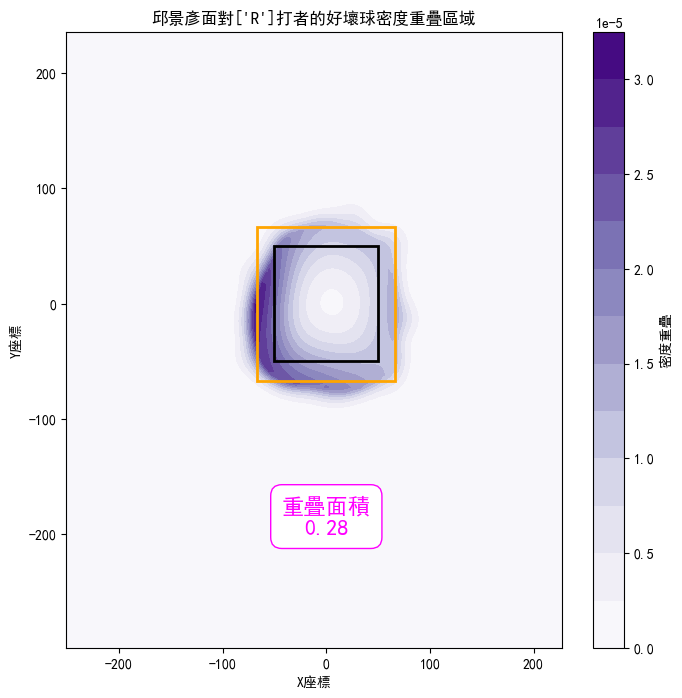

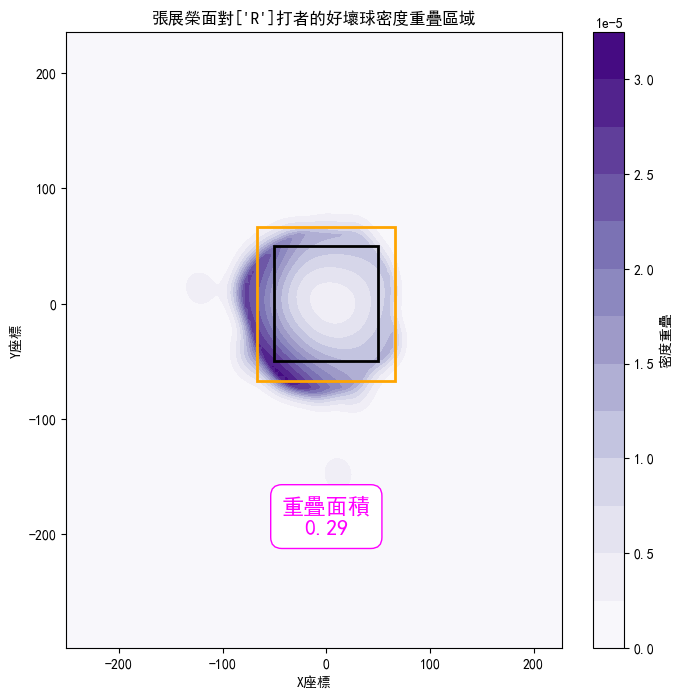

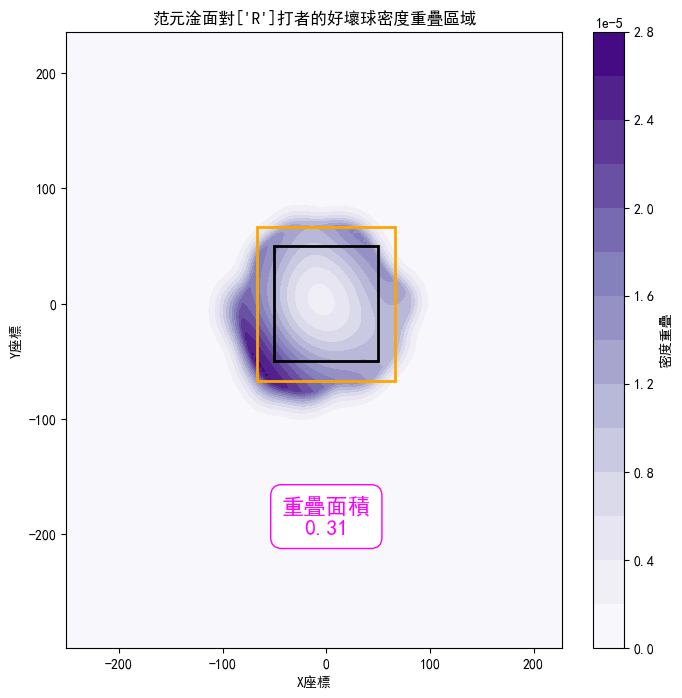

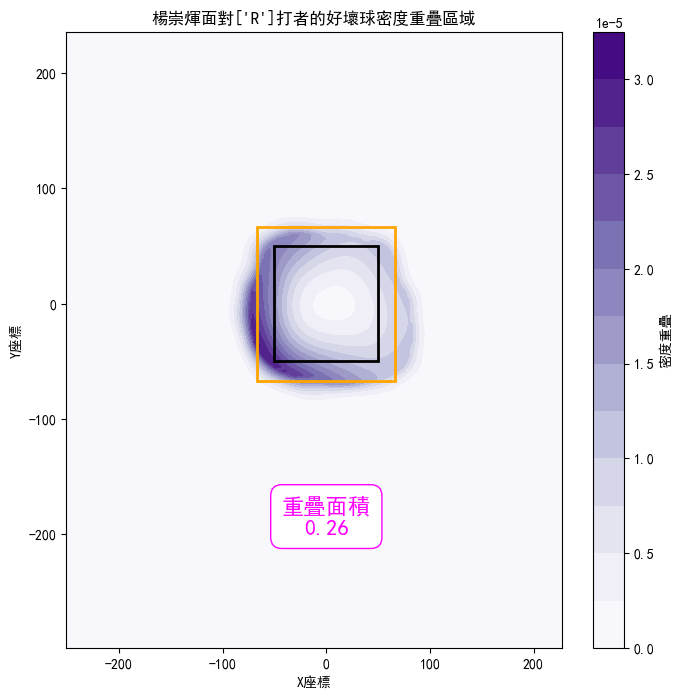

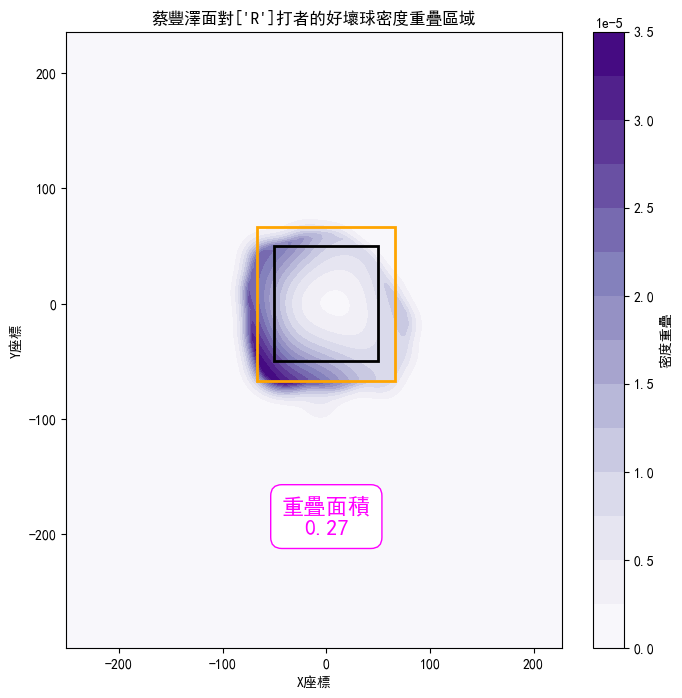

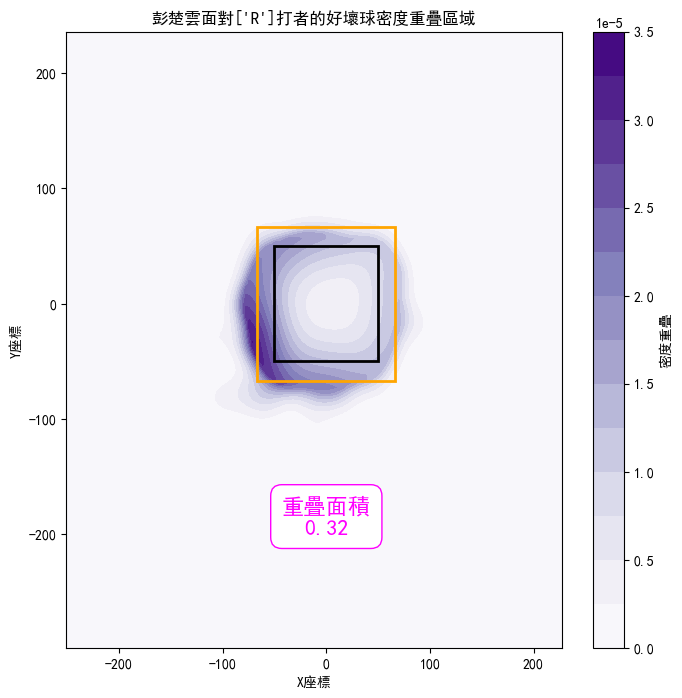

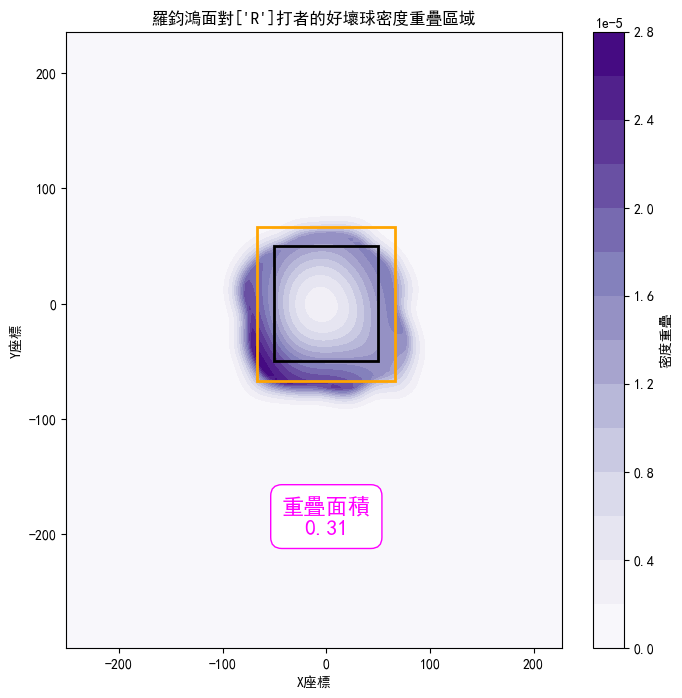

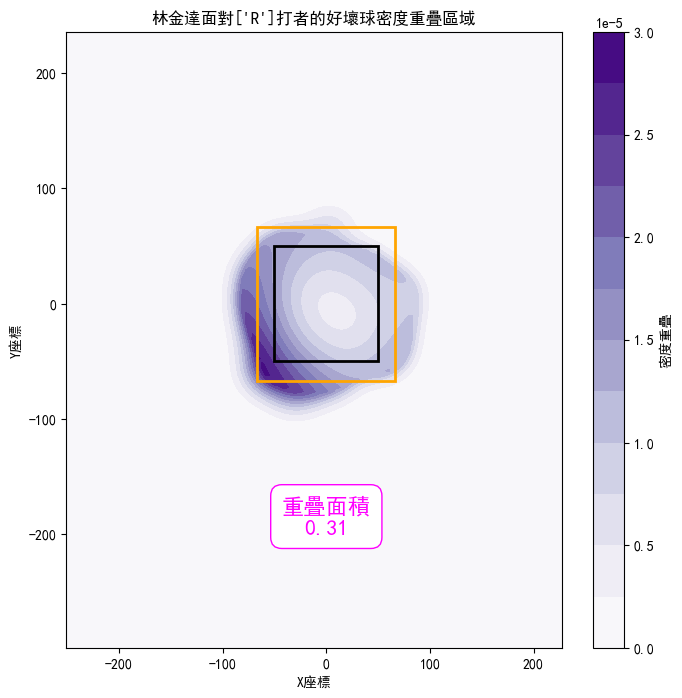

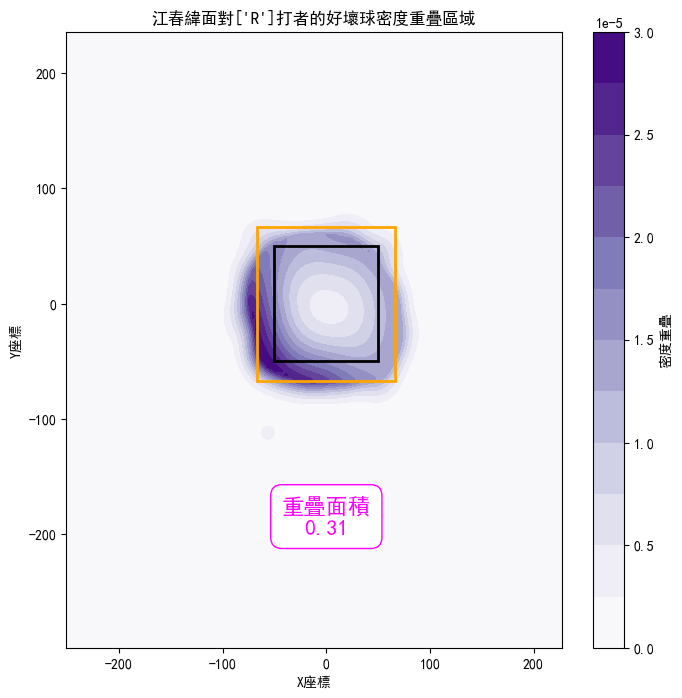

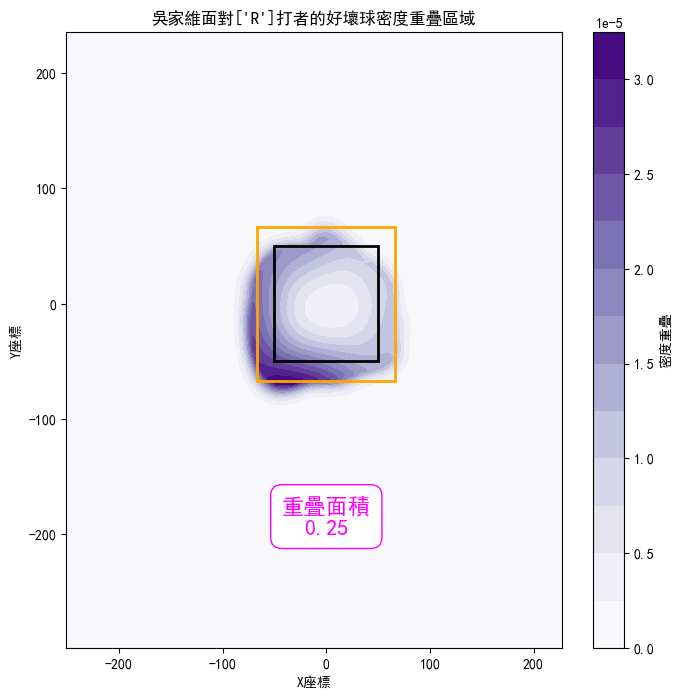

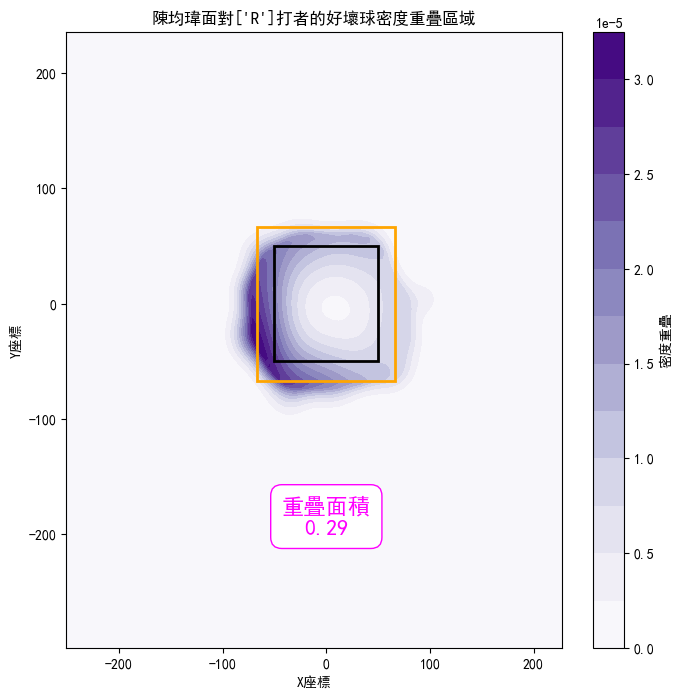

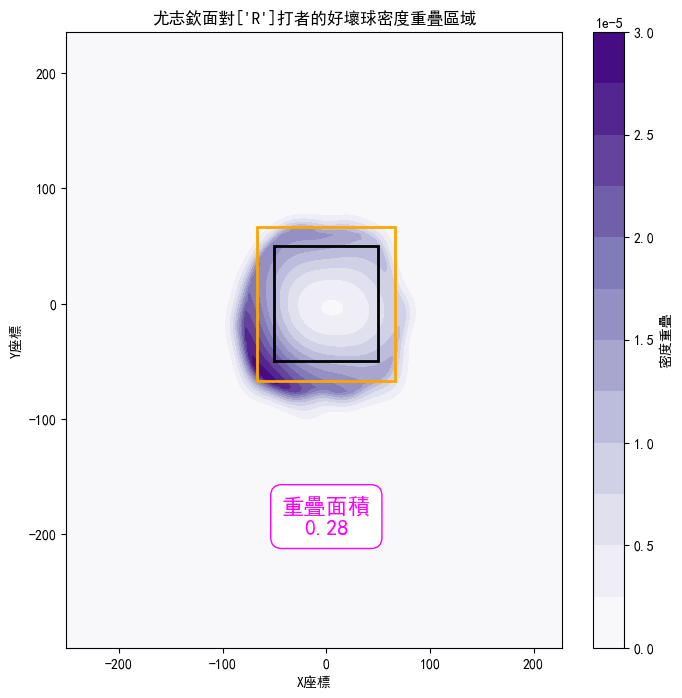

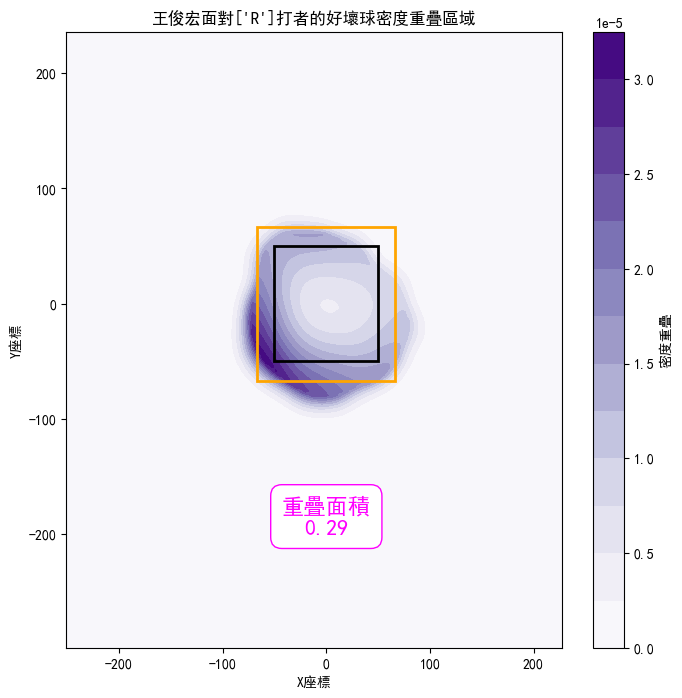

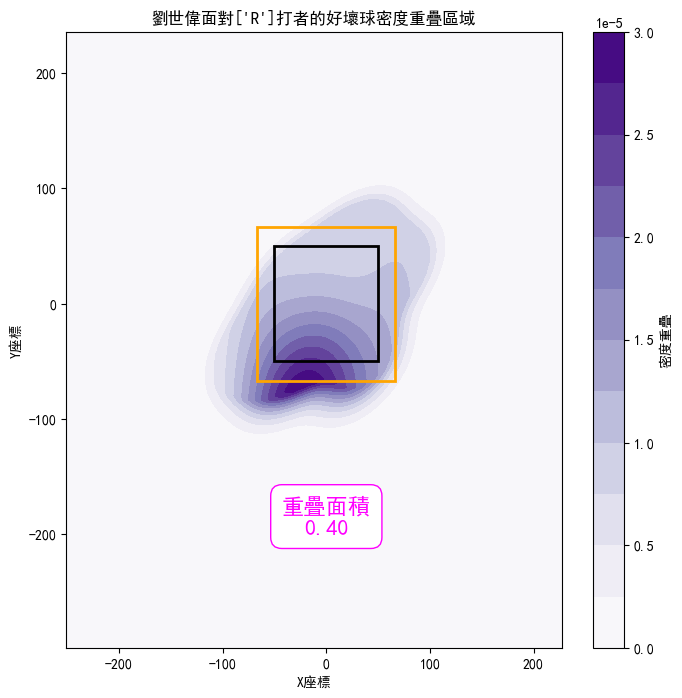

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Polygon

plt.rcParams['font.sans-serif'] = ['Taipei Sans TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

filtered_df = filtered_df.dropna(subset=['coordX', 'coordY', 'call'])

umpires = filtered_df['umpireInChief'].unique()

for umpire in umpires:
    plt.figure(figsize=(8, 8))
    subset = filtered_df[filtered_df['umpireInChief'] == umpire]

    s_coords = subset[subset['call'] == 'S'][['coordX', 'coordY']].values.T
    b_coords = subset[subset['call'] == 'B'][['coordX', 'coordY']].values.T

    s_kde = gaussian_kde(s_coords)
    b_kde = gaussian_kde(b_coords)

    x = np.linspace(filtered_df['coordX'].min(), filtered_df['coordX'].max(), 150)
    y = np.linspace(filtered_df['coordY'].min(), filtered_df['coordY'].max(), 150)
    X, Y = np.meshgrid(x, y)
    positions = np.vstack([X.ravel(), Y.ravel()])

    s_density = s_kde(positions).reshape(X.shape)
    b_density = b_kde(positions).reshape(X.shape)
    overlap = np.minimum(s_density, b_density)

    plt.contourf(X, Y, overlap, levels=13, cmap='Purples')
    plt.colorbar(label='密度重疊')

    # 先繪製密度，再繪製好球帶，避免被覆蓋
    ax = plt.gca()
    shadow_zone = Polygon([[-66.67, 66.67], [66.67, 66.67], [66.67, -66.67], [-66.67, -66.67]], closed=True, fill=None, edgecolor='orange', linewidth=2)
    strike_zone = Polygon([[-50, 50], [50, 50], [50, -50], [-50, -50]], closed=True, fill=None, edgecolor='black', linewidth=2)
    ax.add_patch(shadow_zone)
    ax.add_patch(strike_zone)

    plt.title(f'{umpire}面對{bHand}打者的好壞球密度重疊區域')
    plt.xlabel('X座標')
    plt.ylabel('Y座標')

    overlap_area = overlap.sum() * (x[1] - x[0]) * (y[1] - y[0])
    plt.text(0, -200, f'重疊面積\n{overlap_area:.2f}', fontsize=16, ha='center', color='magenta', bbox=dict(facecolor='white', edgecolor='magenta', boxstyle='round,pad=0.5'))

    plt.show()


In [79]:
call = "S"
#strikes = 2
#inning = [7,8,9]
#pitchtype = ["卡特球"]
#side = "HOME"
pHand = "L"
bHand = ['R']

filtered_df = df2[df2['bHand'].isin(bHand)
                ]
filtered_df

,umpireInChief,stadium,bHand,pHand,strikes,balls,side,inning,coordX,coordY,pType,call,result,球種,實際好壞球
7,蘇建文,臺中洲際棒球場,R,L,0,0,AWAY,1,48.32,-14.85,FF,S,NaN,直球,好球
55,蘇建文,臺中洲際棒球場,R,L,0,0,HOME,2,36.31,-17.02,CU,S,NaN,曲球,好球
57,蘇建文,臺中洲際棒球場,R,L,2,0,HOME,2,-73.17,-67.57,CH,B,NaN,變速球,壞球
59,蘇建文,臺中洲際棒球場,R,L,0,0,AWAY,3,-41.23,-74.97,CU,B,NaN,曲球,壞球
63,蘇建文,臺中洲際棒球場,R,L,2,1,AWAY,3,60.28,77.78,FF,B,NaN,直球,壞球
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193003,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,2,1,AWAY,8,-82.72,-83.26,CH,B,NaN,變速球,壞球
193008,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,0,0,HOME,8,21.85,-8.77,FF,S,NaN,直球,好球
193009,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,0,HOME,8,73.51,-54.30,FF,B,NaN,直球,壞球
193010,彭楚雲,臺北市立天母棒球場 Tianmu Baseball Stadium,R,L,1,1,HOME,8,130.84,-46.00,FF,B,NaN,直球,壞球


In [87]:
# 假設 filtered_df 是你的 DataFrame
# 首先過濾出預測為好球（S）且實際為好球的資料
correct_calls = filtered_df[(filtered_df['call'] == 'S') & (filtered_df['實際好壞球'] == '好球')]

# 計算每位裁判的召回率和精確率
recall_precision = filtered_df.groupby(['umpireInChief']).apply(
    lambda x: pd.Series({
        'recall': len(correct_calls[correct_calls['umpireInChief'] == x.name]) / len(x[x['實際好壞球'] == '好球']),
        'precision': len(correct_calls[correct_calls['umpireInChief'] == x.name]) / len(x[x['call'] == 'S'])
    })
)

recall_precision

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14856\1233879536.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recall_precision = filtered_df.groupby(['umpireInChief']).apply(


,recall,precision
umpireInChief,,
劉世偉,0.888889,0.666667
吳家維,0.901345,0.779070
尤志欽,0.930796,0.693299
張展榮,0.871287,0.742616
彭楚雲,0.882716,0.647059
林金達,0.900000,0.637795
楊崇煇,0.944584,0.725338
江春緯,0.893836,0.758721
王俊宏,0.923077,0.740741


In [89]:
# 假設 filtered_df 是你的 DataFrame
# 首先過濾出預測為好球（S）且實際為好球的資料
correct_calls = filtered_df[(filtered_df['call'] == 'S') & (filtered_df['實際好壞球'] == '好球')]

# 計算每位裁判每一局的召回率和精確率
def calculate_metrics(group):
    correct = correct_calls[correct_calls['umpireInChief'] == group.name[0]]  # 裁判
    true_positives = len(correct)
    
    # 計算實際好球的數量
    actual_positive = len(group[group['實際好壞球'] == '好球'])
    
    # 計算預測為好球的數量
    predicted_positive = len(group[group['call'] == 'S'])
    
    # 計算召回率和精確率
    recall = true_positives / actual_positive if actual_positive > 0 else float('nan')
    precision = true_positives / predicted_positive if predicted_positive > 0 else float('nan')
    
    return pd.Series({'recall': recall, 'precision': precision})

# 計算每位裁判每一局的召回率和精確率
recall_precision = filtered_df.groupby(['umpireInChief', 'inning']).apply(calculate_metrics)

recall_precision


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14856\2246975863.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recall_precision = filtered_df.groupby(['umpireInChief', 'inning']).apply(calculate_metrics)


recall  precision
umpireInChief inning                      
劉世偉           1             NaN        NaN
              2        8.000000   8.000000
              3        2.666667   2.666667
              5        8.000000   4.000000
              7        8.000000   8.000000
...                         ...        ...
陳均瑋           5        8.333333   6.097561
              6        8.333333   6.756757
              7        8.064516   5.813953
              8       10.000000   7.575758
              9       14.705882  13.157895

[161 rows x 2 columns]